# MPy150 Testing

old code


In [1]:
# main_chunk_collection.py

import numpy as np
import pandas as pd
import time
from mpy150_chunk import MP150  # Updated MP150 class using receiveMPData

def main(duration_sec=1.0, total_chunks=10, samplerate=1000, channels=None):
    # Initialize MP150
    mp = MP150(samplerate=samplerate, channels=channels)
    print(f"Initialized MP150: {len(mp._channels)} channels @ {mp._samplerate} Hz")

    # Prepare DataFrame
    df = pd.DataFrame({
      'sample': pd.Series(dtype='int'),
      'data': pd.Series(dtype='object'),
      'timestamp': pd.Series(dtype='float')
    })


    start_time = time.time()

    try:
        curr_time = start_time

        for sample_id in range(total_chunks):
            print(f"Collecting chunk {sample_id}")
            # Acquire chunk using receiveMPData()
            chunk = mp.get_chunk(duration_sec)  # shape: (T, num_channels)

            # Record relative time of acquisition
            timestamp = time.time() - start_time

            # Append chunk as a row in the DataFrame
            df = pd.concat([df, pd.DataFrame([{
                'sample': sample_id,
                'data': chunk,
                'timestamp': timestamp
            }])], ignore_index=True)

            print(f"Collected chunk {sample_id} at +{timestamp:.3f}s with shape {chunk.shape}")
    except KeyboardInterrupt:
        print("Interrupted by user.")
    finally:
        mp.close()
        print("MP150 connection closed.")

    # Summary
    print(f"\nCollected {len(df)} chunks.")
    print("First chunk shape:", df.loc[0, 'data'].shape)
    return df

# Run acquisition
df = main(duration_sec=600, total_chunks=1, samplerate=200, channels=[1])

# Check each chunk shape and timestamp
for i, row in df.iterrows():
    print(f"Chunk {i}: shape = {row['data'].shape}, timestamp = {row['timestamp']:.3f}s")


df.to_json("output.json")


Initialized MP150: 1 channels @ 200 Hz
Collected chunk 0 at +600.010s with shape (120000, 1)
MP150 connection closed.

Collected 1 chunks.
First chunk shape: (120000, 1)
Chunk 0: shape = (120000, 1), timestamp = 600.010s


In [2]:
data = np.array(df['data'][0])
data = data.T
data.shape

(1, 120000)

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

def butter_bandpass(low, high, fs, order=5):
    return butter(order, [low, high], fs=fs, btype='band')

def butter_bandpass_filter(data, low, high, fs, order = 4):
    b, a = butter_bandpass(low, high, fs, order=order)
    y = lfilter(b, a, data)
    return y

data_filt = butter_bandpass_filter(data[0], 1, 20, 200)

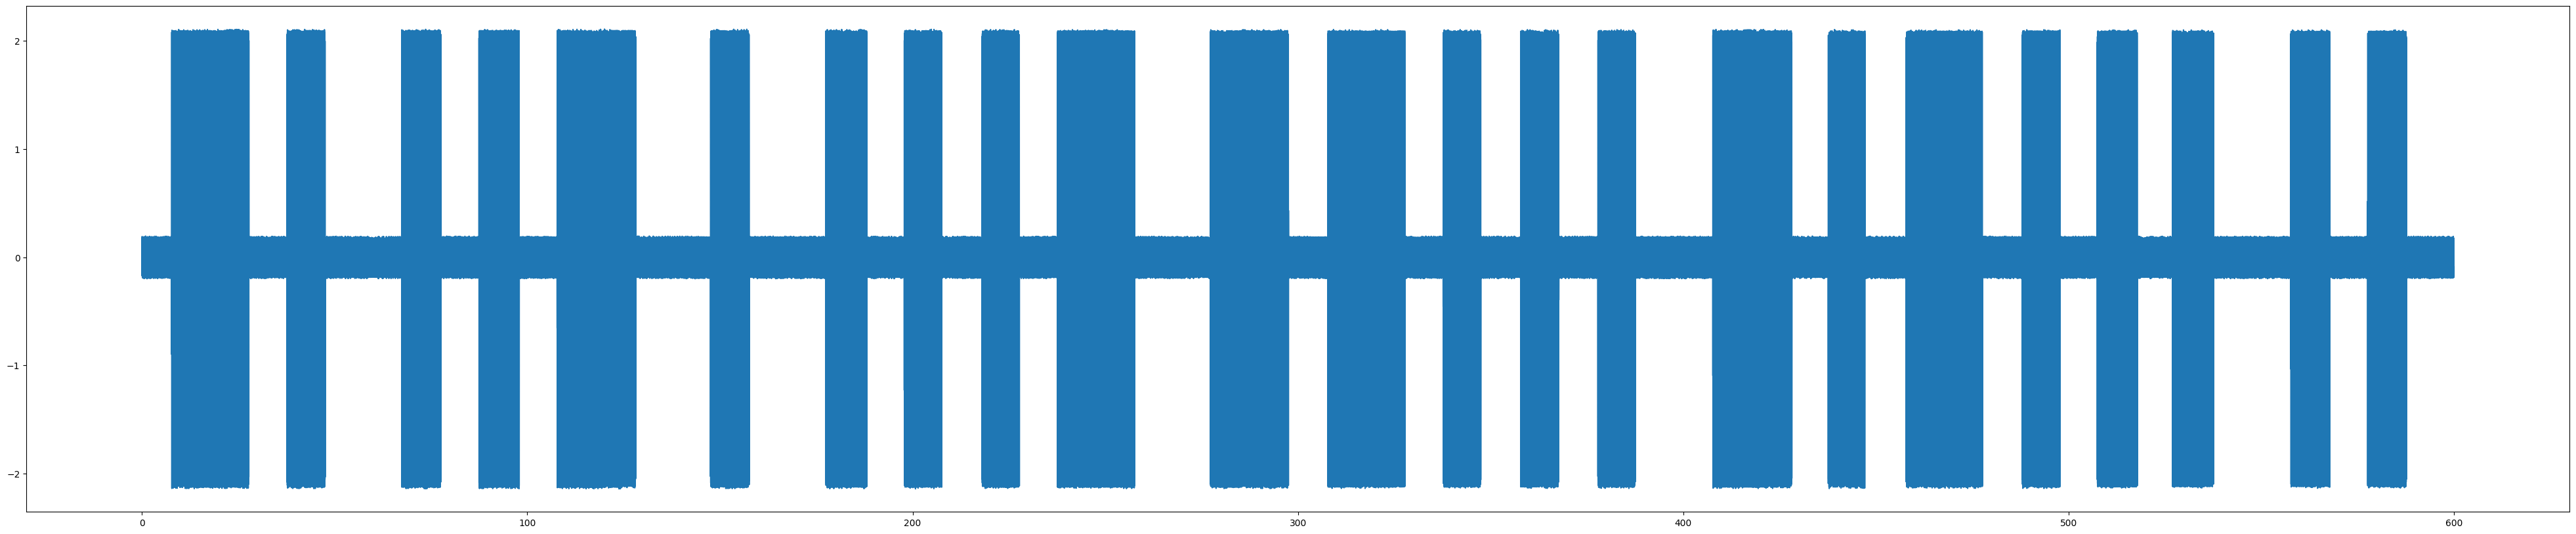

In [6]:
x = np.arange(0, len(data[0]))
plt.figure(figsize=(50, 10))
plt.plot(x/200, data[0])

plt.show()

In [7]:
np.savez(
        'cont_data.npz',
        eeg=data[0],
        samplerate=200,
    )